<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Chapter%202%20Understanding%20Time%20Series%20Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Understanding Time Series Graphs

Time series data consists of observations collected over time. Before applying any forecasting model, it is essential to visualize the data and understand its behavior. Graphical analysis helps identify patterns that may not be visible through numerical summaries alone.

The main objective of this chapter is to understand how different time series graphs can be used to explore and analyze data. These graphs help identify important components such as:

- **Trend:** A long-term increase or decrease in the data over time.
- **Seasonality:** Regular patterns that repeat at fixed intervals, such as monthly or yearly temperature changes.
- **Cyclic Patterns:** Fluctuations that occur over varying periods and do not follow a fixed schedule.
- **Random Variations:** Unpredictable changes that cannot be explained by trend or seasonality.

Various visualization techniques such as Time Series Plots, Seasonal Plots, Seasonal Subseries Plots, Lag Plots, and Autocorrelation Function (ACF) Plots are used to examine these patterns. Each graph provides a different perspective and helps in understanding the underlying structure of the data.

In this assignment, the Daily Delhi Climate dataset is analyzed using these visualization techniques to identify and compare different time series patterns present in temperature data.

# **Step 1: Import Libraries**

In this step, the required Python libraries are imported for data manipulation, visualization, and time series analysis.

- **Pandas** is used to load and manage the climate dataset.
- **NumPy** is used for numerical computations.
- **Matplotlib** is used to create graphs and visualizations.
- **Seaborn** is used to improve the appearance of statistical plots.
- **Lag Plot** is imported to examine the relationship between current and previous observations.
- **ACF (Autocorrelation Function)** is imported to measure the correlation between observations at different time lags.

These libraries provide the necessary tools to visualize and compare different time series graphs throughout this chapter.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('default')

# **Step 2: Load and Explore the Dataset**

In this step, the Daily Delhi Climate dataset is loaded into a Pandas DataFrame using the `read_csv()` function. The dataset is then explored using `head()`, `info()`, and `describe()` to understand its structure, data types, and statistical properties.

The dataset contains climate-related variables including mean temperature, humidity, wind speed, and mean atmospheric pressure recorded over time.

### Result

The dataset contains **1,462 observations** and **5 columns**: Date, Mean Temperature, Humidity, Wind Speed, and Mean Pressure.

All columns contain **1,462 non-null values**, indicating that there are no missing values in the dataset. The mean temperature is approximately **25.50°C**, the average humidity is **60.77%**, and the average wind speed is **6.80 units**.

The statistical summary provides information about the distribution of each variable and confirms that the dataset is complete and suitable for time series analysis and visualization.

In [5]:
train_df = pd.read_csv("/content/DailyDelhiClimateTrain.csv")

train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


# **Step 3: Convert Date Column and Set Time Index**

In this step, the `date` column is converted from text format to datetime format using `pd.to_datetime()`. The date column is then set as the index of the DataFrame.

Setting the date as the index is an important step in time series analysis because it allows the data to be organized chronologically and enables time-based operations such as resampling, trend analysis, and seasonal analysis.

### Result

The date column was successfully converted into datetime format and set as the index of the dataset. The output shows climate observations starting from **1 January 2013** along with their corresponding temperature, humidity, wind speed, and pressure values.

The dataset is now properly structured as a time series dataset and is ready for visualization and pattern analysis.

In [6]:
train_df['date'] = pd.to_datetime(train_df['date'])

train_df.set_index('date', inplace=True)

train_df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


# **Step 4: Time Series Plot of Mean Temperature**

In this step, a Time Series Plot is created to visualize how the mean temperature changes over time. A time series plot is the most basic and important graph in time series analysis because it helps identify patterns such as trend, seasonality, cycles, and unusual fluctuations.

According to the chapter, the first step in analyzing any time series data is to visually inspect the graph and identify its underlying patterns.

### Result

The graph shows the daily mean temperature of Delhi from **2013 to 2017**. A clear repeating pattern can be observed, where temperatures rise during the middle of each year and fall during the beginning and end of the year.

This recurring pattern indicates the presence of **seasonality** in the data. The temperature peaks are observed during summer months, while the lowest temperatures occur during winter months. The series does not appear completely random and exhibits a strong seasonal structure, making it suitable for further time series analysis using seasonal plots, lag plots, and autocorrelation analysis.

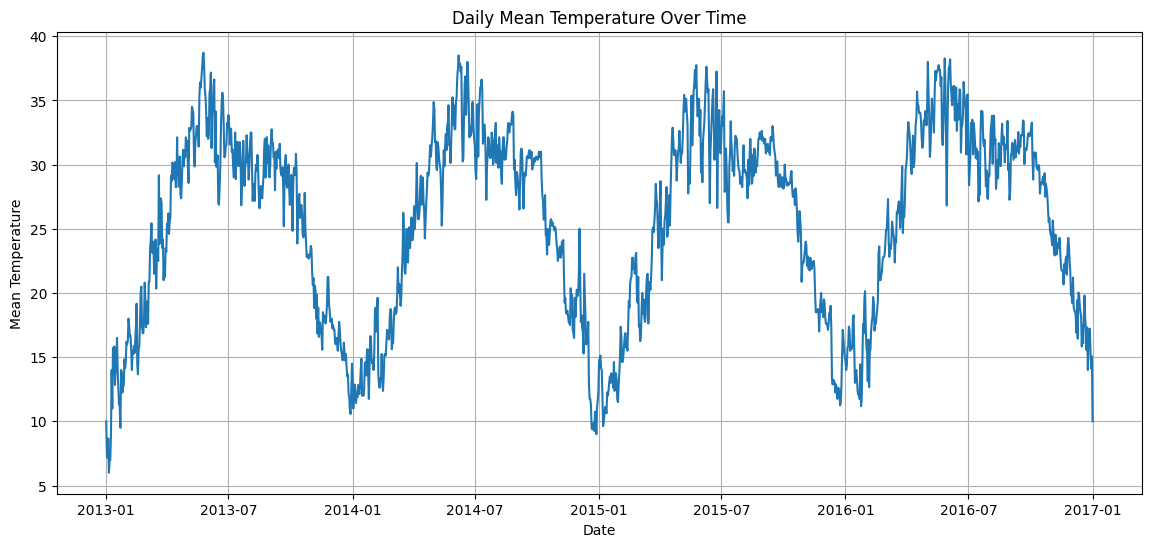

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    train_df.index,
    train_df['meantemp']
)

plt.title("Daily Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")

plt.grid(True)

plt.show()

# **Step 5: Calculate Monthly Average Temperature**

In this step, the daily temperature data is converted into monthly average temperature values using the `resample()` function. This process reduces daily fluctuations and helps reveal broader patterns in the time series.

Monthly aggregation makes it easier to identify long-term trends and seasonal behavior compared to daily observations.

### Result

The output displays the average temperature for each month. For example, the average temperature increased from approximately **12.07°C in January 2013** to **33.78°C in May 2013**, indicating a gradual rise in temperature during the first half of the year.

By converting daily data into monthly averages, the dataset becomes smoother and more suitable for identifying seasonal patterns and comparing temperature changes across different months and years.

In [8]:
monthly_temp = train_df['meantemp'].resample('M').mean()

monthly_temp.head()

/tmp/ipykernel_409/3200634158.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = train_df['meantemp'].resample('M').mean()


,meantemp
date,
2013-01-31,12.074770
2013-02-28,16.867560
2013-03-31,22.814209
2013-04-30,28.895119
2013-05-31,33.776767


# **Step 6: Visualize Monthly Average Temperature**

In this step, a line graph is created using the monthly average temperature values. Compared to the daily temperature graph, this visualization is smoother and makes long-term patterns easier to observe.

Monthly aggregation reduces short-term fluctuations and highlights seasonal behavior more clearly.

### Result

The graph shows a clear repeating pattern across multiple years. Temperatures increase steadily during the first half of each year, reach their highest values around **May–June**, and then gradually decrease during the later months of the year.

This repeating annual pattern is a strong indication of **seasonality**, where temperature changes follow a regular cycle each year. Compared to the daily temperature plot, the seasonal behavior is much more visible and easier to interpret in the monthly average temperature graph.

Therefore, the monthly temperature graph provides a clearer view of the underlying seasonal structure of the climate data.

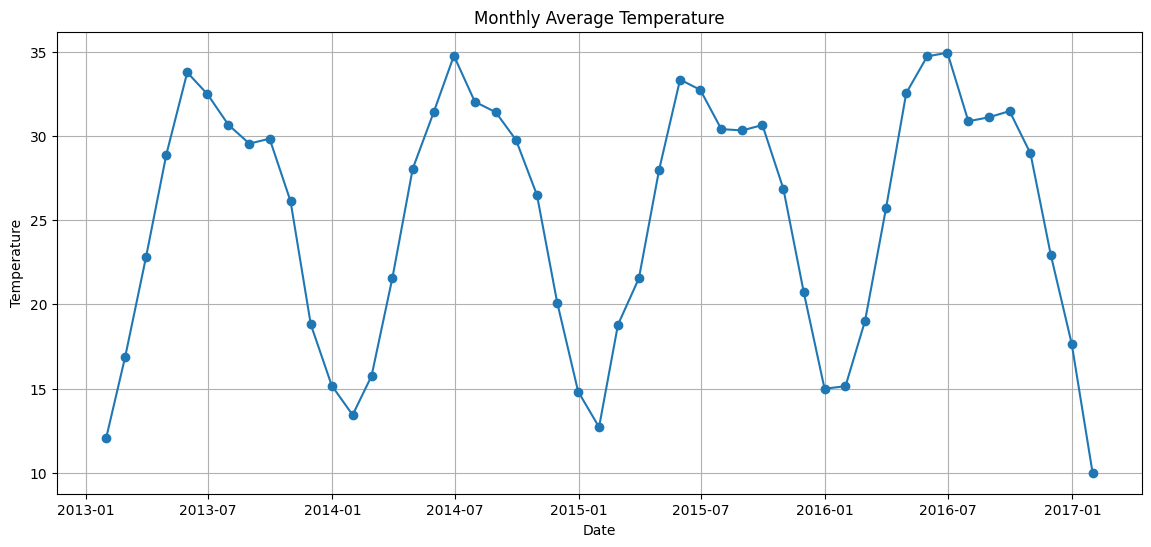

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_temp.index,
    monthly_temp,
    marker='o'
)

plt.title("Monthly Average Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.grid(True)

plt.show()

# **Step 7: Seasonal Plot**

In this step, a Seasonal Plot is created by plotting the monthly average temperature for each year on the same graph. Each colored line represents a different year, allowing seasonal patterns to be compared across years.

According to time series analysis, seasonal plots help determine whether seasonal behavior remains consistent over time and whether specific months repeatedly experience higher or lower values.

### Result

The graph shows a very similar pattern across all years. Temperatures increase from January, reach their highest levels around **May and June**, and then gradually decrease towards December.

The lines for different years closely follow the same shape, indicating that the seasonal pattern remains relatively stable over time. This confirms the presence of strong annual seasonality in the climate data.

Compared to a standard time series plot, the seasonal plot makes it much easier to compare the same months across different years and identify recurring seasonal behavior.

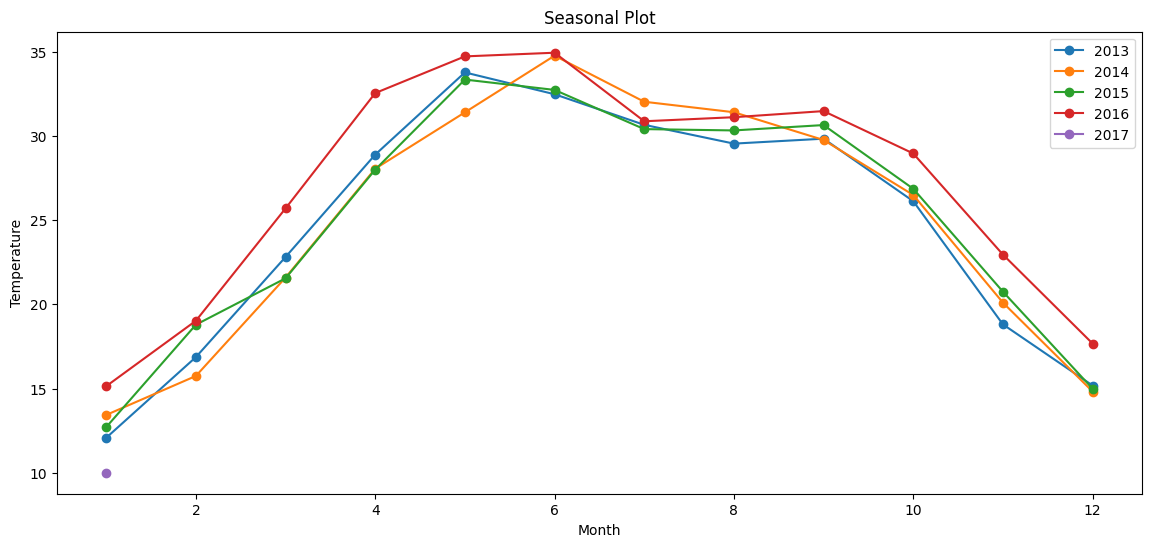

In [10]:
seasonal_df = monthly_temp.to_frame()

seasonal_df['Year'] = seasonal_df.index.year
seasonal_df['Month'] = seasonal_df.index.month

plt.figure(figsize=(14,6))

for year in seasonal_df['Year'].unique():
    data = seasonal_df[seasonal_df['Year'] == year]

    plt.plot(
        data['Month'],
        data['meantemp'],
        marker='o',
        label=year
    )

plt.title("Seasonal Plot")
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.legend()

plt.show()

# **Step 8: Seasonal Subseries Plot**

In this step, a Seasonal Subseries Plot is created using boxplots. Unlike the seasonal plot, which compares yearly patterns, this graph analyzes the distribution of temperature values for each month across all years.

The Seasonal Subseries Plot helps identify which months consistently experience higher or lower temperatures and how much variation exists within each month.

### Result

The boxplots reveal a clear seasonal pattern in the climate data. The lowest temperatures are observed during **January and December**, while the highest temperatures occur during **May and June**.

The median temperatures gradually increase from January to June and then decrease towards December, confirming the annual seasonal cycle observed in previous graphs. Most months show relatively small variability, indicating that temperatures remain fairly consistent from year to year during the same month.

Compared to the Seasonal Plot, the Seasonal Subseries Plot provides a more detailed view of the distribution and variability of temperatures within each month, making seasonal patterns easier to analyze and compare.

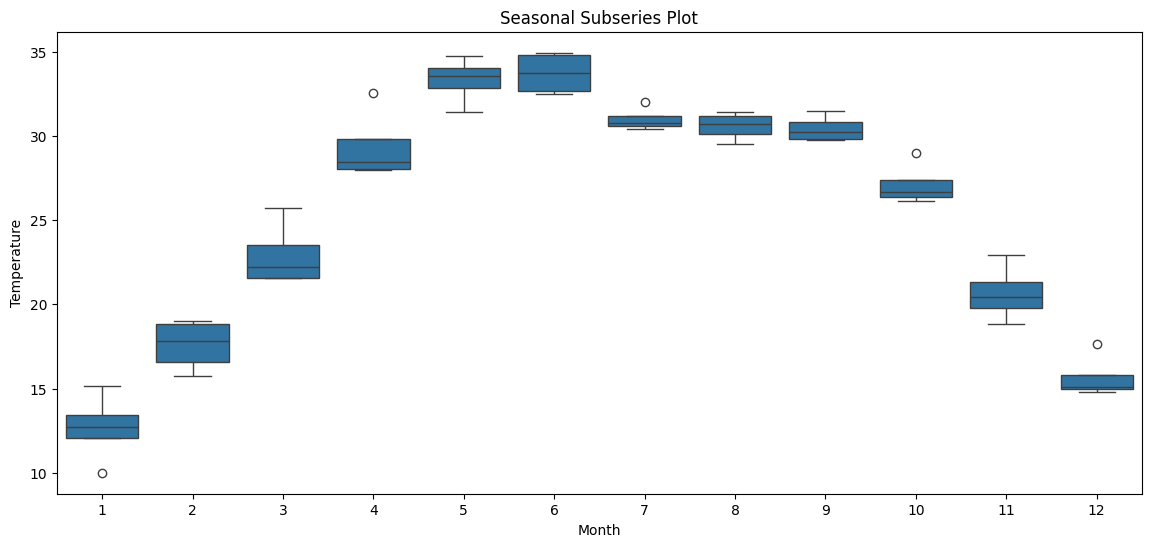

In [11]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x=seasonal_df['Month'],
    y=seasonal_df['meantemp']
)

plt.title("Seasonal Subseries Plot")
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.show()

# **Step 9: Lag Plot**

In this step, a Lag Plot is created to examine the relationship between a temperature value and its previous observation. The lag value of 1 means that each temperature observation is compared with the temperature of the previous month.

Lag plots are useful for identifying autocorrelation in time series data. If the points form a recognizable pattern rather than appearing randomly scattered, it indicates that consecutive observations are related to each other.

### Result

The points in the lag plot form a clear positive pattern rather than a random scatter. This indicates that the temperature of a particular month is strongly related to the temperature of the previous month.

The presence of this relationship suggests that the data exhibits **autocorrelation**, meaning past temperature values influence future values. This behavior is common in climate and environmental datasets where changes occur gradually over time.

Compared to the previous graphs, the Lag Plot provides direct evidence that the time series is not random and contains meaningful temporal dependence.

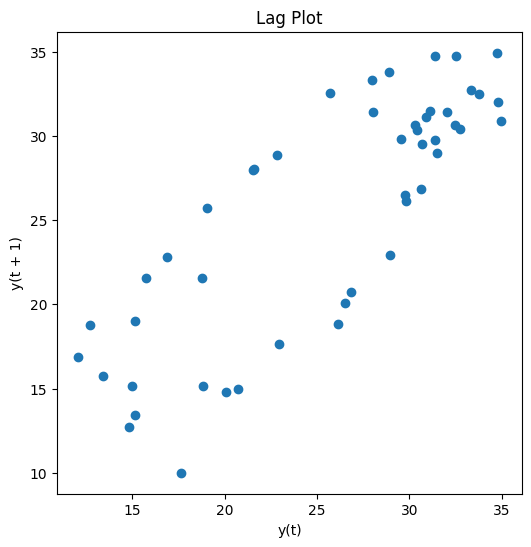

In [12]:
plt.figure(figsize=(6,6))

lag_plot(
    monthly_temp,
    lag=1
)

plt.title("Lag Plot")

plt.show()

# **Step 10: Autocorrelation Function (ACF) Plot**

In this step, an Autocorrelation Function (ACF) Plot is created to measure the correlation between temperature observations and their previous values at different time lags.

The ACF plot helps determine whether past observations influence future observations and is commonly used to identify seasonality and repeating patterns in time series data.

### Result

The ACF plot shows several significant positive and negative correlations across different lags. The correlation is particularly strong at lower lags, indicating that recent temperature values have a strong influence on future values.

A noticeable repeating pattern can also be observed, suggesting the presence of seasonality in the dataset. The alternating positive and negative correlations indicate that temperature values follow a cyclical pattern over time rather than behaving randomly.

Compared to the Lag Plot, which shows the relationship between consecutive observations, the ACF Plot provides a more detailed view of how observations are correlated across multiple time periods. This confirms that the temperature series contains strong temporal dependence and seasonal behavior.

<Figure size 1200x600 with 0 Axes>

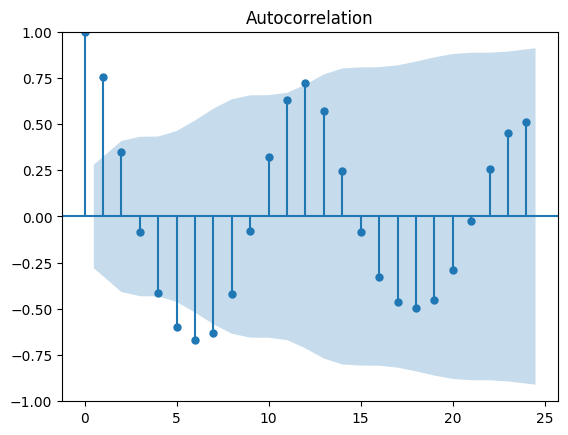

In [13]:
plt.figure(figsize=(12,6))

plot_acf(
    monthly_temp,
    lags=24
)

plt.show()

# **Step 11: Generate White Noise Series**

In this step, a White Noise series is generated using random values from a normal distribution. White noise represents completely random data with no trend, seasonality, or relationship between observations.

White noise is commonly used in time series analysis as a reference model to compare against real-world data and determine whether meaningful patterns exist.

### Result

The output displays the first few randomly generated values of the white noise series. The values fluctuate randomly around zero and do not follow any visible pattern.

Unlike the climate dataset, these observations are generated independently and do not contain trend, seasonality, or temporal dependence. This white noise series will be used in the following steps to compare random behavior with the structured patterns observed in temperature data.

In [14]:
# White Noise Generation
white_noise = np.random.normal(
    0,
    1,
    len(monthly_temp)
)

white_noise = pd.Series(
    white_noise,
    index=monthly_temp.index
)

white_noise.head()

,0
date,
2013-01-31,-0.256669
2013-02-28,-0.842357
2013-03-31,1.332050
2013-04-30,-0.194434
2013-05-31,-0.829224


# **Step 12: Visualize White Noise Series**

In this step, the generated white noise data is visualized using a line graph. White noise is a completely random time series where each observation is independent of the previous observations.

This graph is used to compare random data with the structured temperature time series analyzed in previous steps.

### Result

The graph displays irregular fluctuations around zero with no visible trend, seasonal pattern, or repeating cycle. The values rise and fall randomly throughout the time period.

Unlike the temperature graphs, which showed clear seasonal behavior and recurring patterns, the white noise series appears completely random. This confirms that white noise does not contain meaningful information for forecasting and serves as a useful benchmark for comparison with real-world time series data.

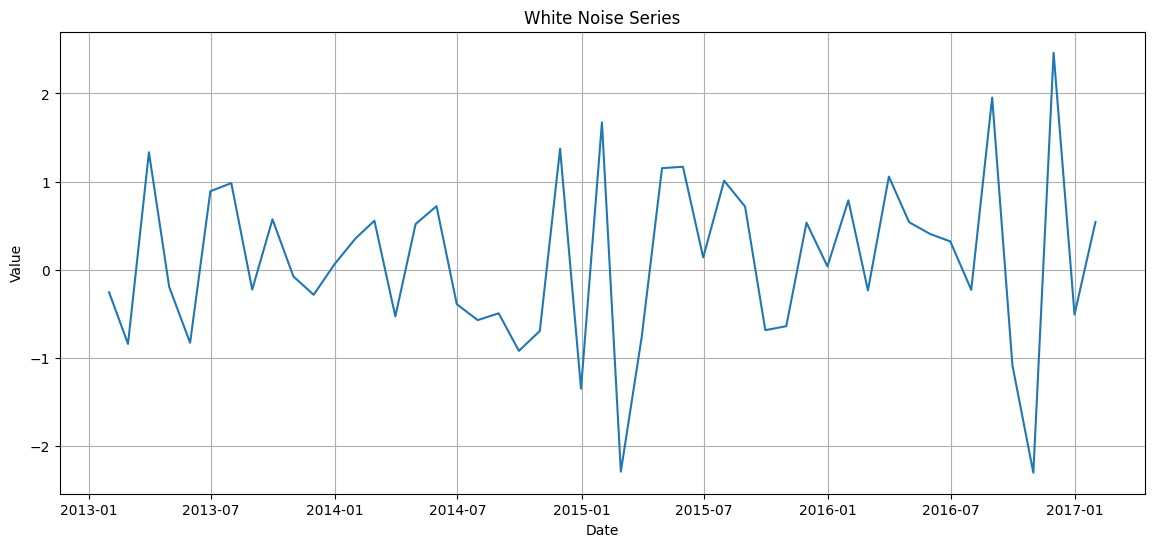

In [15]:
# White Noise Plot
plt.figure(figsize=(14,6))

plt.plot(
    white_noise.index,
    white_noise
)

plt.title("White Noise Series")
plt.xlabel("Date")
plt.ylabel("Value")

plt.grid(True)

plt.show()

# **Step 13: Autocorrelation Function (ACF) of White Noise**

In this step, an ACF plot is created for the white noise series. The purpose of this graph is to determine whether any correlation exists between observations at different time lags.

Since white noise is completely random, no significant autocorrelation should be present.

### Result

The ACF plot shows that almost all autocorrelation values remain close to zero and lie within the confidence interval. This indicates that there is no significant relationship between observations at different lags.

Unlike the temperature ACF plot, which displayed strong correlations and seasonal patterns, the white noise ACF plot shows no meaningful structure. This confirms that the white noise series is random and does not contain trend, seasonality, or temporal dependence.

The comparison between the temperature ACF plot and the white noise ACF plot clearly demonstrates how autocorrelation helps distinguish structured time series data from random data.

<Figure size 1200x600 with 0 Axes>

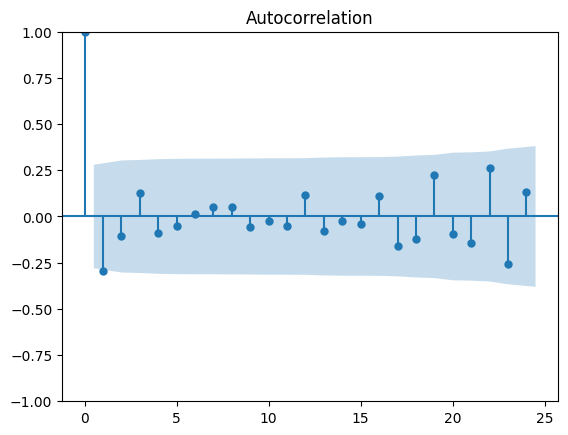

In [16]:
# White Noise ACF
plt.figure(figsize=(12,6))

plot_acf(
    white_noise,
    lags=24
)

plt.show()